# 02 - Data Preparation


In [1]:
!uv pip install huggingface_hub webdataset librosa soundfile xgboost statsmodels pyarrow fastparquet

Using Python 3.12.3 environment at: /home/desan/Hackathons/codefest/.venv
Checked 8 packages in 20ms


In [2]:
# ── Section 0-B: imports ──────────────────────────────────────────────────────
import tarfile
import sys, os, re, json, io, time, logging, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import scipy.signal as ss
import scipy.stats as st
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARN] XGBoost not available; falling back to HistGradientBoostingClassifier")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import webdataset as wds
from huggingface_hub import hf_hub_download, list_repo_files, snapshot_download

import joblib

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python  : {sys.version}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"librosa : {librosa.__version__}")
print(f"sklearn : {__import__('sklearn').__version__}")
if HAS_XGB:
    print(f"xgboost : {xgb.__version__}")

Python  : 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
NumPy   : 2.5.3
Pandas  : 3.0.5
librosa : 1.0.0
sklearn : 1.9.0
xgboost : 3.4.1


In [3]:
# ── Section 0-C: global configuration ────────────────────────────────────────
# All tuneable parameters in one place.

RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

# Dataset
HF_REPO       = "DesanSilva/sscc-compact-av"
HF_REPO_TYPE  = "dataset"
DATA_DIR      = Path("data/sscc_compact")
OUT_DIR       = Path("outputs")

# Signal parameters (from SSCC spec)
VIB_RATE_HZ       = 100_000     # original acquisition rate
VIB_STORED_HZ     = 10_000      # stored/downsampled rate (compact set)
AUD_RATE_HZ       = 44_100      # recorder (Zoom H5) rate
CLIP_DURATION_S   = 5.0
N_VIB_CHANNELS    = 4

# Feature extraction windows
WINDOW_SIZE_S = 1.0
HOP_SIZE_S    = 0.5

# Vibration frequency bands (Hz) - physically motivated for chain conveyor
VIB_BANDS = {
    "low":    (0,    500),
    "mid":    (500,  2000),
    "high":   (2000, 5000),
}

# Audio frequency bands (Hz)
AUD_BANDS = {
    "sub":    (0,    200),
    "low":    (200,  1000),
    "mid":    (1000, 4000),
    "high":   (4000, 8000),
    "air":    (8000, 16000),
}

# Envelope analysis bandpass (Hz) - mechanical fault region
ENV_BANDPASS_HZ = (500, 4000)

# MFCC
N_MFCC = 13

# Temporal smoothing
EMA_ALPHA     = 0.4
MAVG_WINDOW   = 3
NOM_N         = 3
NOM_M         = 5
PERSIST_K     = 3

# Split sizes
VALID_FRAC = 0.15
TEST_FRAC  = 0.15

# XGBoost / fallback
XGB_ROUNDS        = 500
XGB_EARLY_STOP    = 30
XGB_N_FOLDS       = 5

# Output subdirectories
for sub in ["eda", "features", "models", "metrics", "reports"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler()]
)
log = logging.getLogger("sscc_poc")

# Plotting defaults
matplotlib.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
PALETTE = {"normal": "#2ecc71", "dry": "#e74c3c", "lean": "#e67e22",
           "loose": "#9b59b6", "screwdrop": "#3498db"}

print("Configuration complete.")

Configuration complete.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# Use a clean, professional plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

---
# 1. Shard Loading Mechanism

## Dataset structure

The compact dataset is hosted on Hugging Face as WebDataset `.tar` shards. Each shard member uses a key naming convention:

```
<sample_id>.audio.flac          → recorder audio (Zoom H5, 44.1 kHz)
<sample_id>.vib.npz             → 4-channel vibration array, shape (4, T)
<sample_id>.json                → per-sample metadata dict
<sample_id>.<device>.frame_NN.webp  → video frames (ios / android)
```

The patterns are:
```python
FRAME_PATTERN = re.compile(
    r'^(?P<sample_id>.+)\.(?P<device>ios|android)\.frame_(?P<index>\d{2})\.webp$'
)
BASE_SUFFIXES = {
    '.audio.flac': 'audio',
    '.vib.npz':    'vibration',
    '.json':       'metadata',
}
```

We parse these directly from the tar byte stream using `webdataset`. Video frames are catalogued but **not** used in the primary classical model - this is consistent with the POC scope (audio + vibration only).

In [5]:
# ── Section 1-A: file-level patterns ─────────────────────────────────────────

FRAME_PATTERN = re.compile(
    r"^(?P<sample_id>.+)\.(?P<device>ios|android)\.frame_(?P<index>\d{2})\.webp$"
)
BASE_SUFFIXES = {
    ".audio.flac": "audio",
    ".vib.npz":    "vibration",
    ".json":       "metadata",
}

def _parse_member_key(key: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    """Return (sample_id, modality, extra) for a WebDataset member key.

    extra is None for base members, device string for frame members.
    Returns (None, None, None) if the key does not match known patterns.
    """
    m = FRAME_PATTERN.match(key)
    if m:
        return m.group("sample_id"), "video_frame", m.group("device")
    for suffix, modality in BASE_SUFFIXES.items():
        if key.endswith(suffix):
            sample_id = key[: -len(suffix)]
            return sample_id, modality, None
    return None, None, None


def _decode_vib(raw: bytes) -> np.ndarray:
    """Decode vibration .npz bytes → float32 array, shape (4, T)."""
    buf = io.BytesIO(raw)
    npz = np.load(buf, allow_pickle=False)
    # Accept either key 'data' or the first key
    key = "data" if "data" in npz else list(npz.keys())[0]
    arr = npz[key].astype(np.float32)
    if arr.ndim == 1:
        arr = arr[np.newaxis, :]  # single-channel fallback
    return arr


def _decode_audio(raw: bytes) -> Tuple[np.ndarray, int]:
    """Decode audio .flac bytes → (float32 mono array, sample_rate)."""
    buf = io.BytesIO(raw)
    wav, sr = sf.read(buf, dtype="float32", always_2d=False)
    if wav.ndim == 2:  # stereo → mono
        wav = wav.mean(axis=1)
    return wav, sr


def _decode_meta(raw: bytes) -> dict:
    """Decode JSON bytes → dict."""
    return json.loads(raw.decode("utf-8"))


print("Shard loading helpers defined.")

Shard loading helpers defined.


In [6]:
# ── Section 1-B: download metadata files ─────────────────────────────────────
# We download lightweight metadata parquets first (no shards yet).
# hf_hub_download retries on transient network errors automatically.

META_FILES = [
    "metadata.parquet",
    "selected_manifest.parquet",
    "source_manifest.parquet",
    "shard_manifest.parquet",
    "sampling_policy.json",
    "etl_summary.json",
]

local_meta: Dict[str, Path] = {}
for fname in META_FILES:
    try:
        local_path = Path(hf_hub_download(
            repo_id=HF_REPO,
            filename=fname,
            repo_type=HF_REPO_TYPE,
            local_dir=DATA_DIR / "meta",
            local_dir_use_symlinks=False,
        ))
        local_meta[fname] = local_path
        log.info("Downloaded: %s", fname)
    except Exception as exc:
        log.warning("Could not download %s: %s", fname, exc)

print(f"\nDownloaded {len(local_meta)} / {len(META_FILES)} metadata files.")
for k, v in local_meta.items():
    print(f"  {k:40s} → {v}")

2026-09-11 22:08:41,285 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/DesanSilva/sscc-compact-av/resolve/main/metadata.parquet "HTTP/1.1 302 Found"
2026-09-11 22:08:41,288 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-09-11 22:08:41,295 [INFO] Downloaded: metadata.parquet
2026-09-11 22:08:41,691 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/DesanSilva/sscc-compact-av/resolve/main/selected_manifest.parquet "HTTP/1.1 302 Found"
2026-09-11 22:08:41,696 [INFO] Downloaded: selected_manifest.parquet
2026-09-11 22:08:42,245 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/DesanSilva/sscc-compact-av/resolve/main/source_manifest.parquet "HTTP/1.1 302 Found"
2026-09-11 22:08:42,256 [INFO] Downloaded: source_manifest.parquet
2026-09-11 22:08:42,613 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/DesanSilva/sscc-compact-av/resolve/main/shard_manifest


Downloaded 6 / 6 metadata files.
  metadata.parquet                         → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/metadata.parquet
  selected_manifest.parquet                → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/selected_manifest.parquet
  source_manifest.parquet                  → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/source_manifest.parquet
  shard_manifest.parquet                   → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/shard_manifest.parquet
  sampling_policy.json                     → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/sampling_policy.json
  etl_summary.json                         → /home/desan/Hackathons/octwave/oscillens/data/processed/sscc-compact-av/meta/etl_summary.json


In [7]:
# ── Section 1-C: discover shard files ────────────────────────────────────────
# List all files in the repo; identify shards by extension.

all_repo_files = list(list_repo_files(HF_REPO, repo_type=HF_REPO_TYPE))
shard_files = sorted(f for f in all_repo_files if f.endswith(".tar"))

print(f"Total repo files : {len(all_repo_files)}")
print(f"Shard (.tar) files : {len(shard_files)}")
for s in shard_files:
    print(f"  {s}")

2026-09-11 22:08:44,046 [INFO] HTTP Request: GET https://huggingface.co/api/datasets/DesanSilva/sscc-compact-av/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


Total repo files : 35
Shard (.tar) files : 6
  shards/base-00000.tar
  shards/base-00001.tar
  shards/base-00002.tar
  shards/base-00003.tar
  video_shards/video-00000.tar
  video_shards/video-00001.tar


In [8]:
# ── Section 1-D: stream one shard to verify structure ─────────────────────────
# We stream rather than download all shards upfront to save space.
# HF public repos expose shards at a predictable resolve URL.

HF_BASE = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main"

shard_urls = [f"{HF_BASE}/{s}" for s in shard_files]

# Quick structural probe: read only first shard to catalogue member keys.
probe_url = shard_urls[0] if shard_urls else None

key_catalogue: Dict[str, List[str]] = {}  # sample_id → list of modalities
n_audio_found = 0
n_vib_found   = 0
n_meta_found  = 0
n_frame_found = 0

if probe_url:
    probe_ds = (
        wds.WebDataset(probe_url, handler=wds.warn_and_continue)
        .to_tuple("__key__", "__url__")
    )
    # Actually we need raw member access - use wds.tariterators
    import tarfile
    import urllib.request
    
    PROBE_LIMIT = 200  # inspect first N members
    probe_path = DATA_DIR / "meta" / "probe_shard.tar"
    if not probe_path.exists():
        log.info("Downloading probe shard...")
        urllib.request.urlretrieve(probe_url, probe_path)
    
    with tarfile.open(probe_path, "r:") as tf:
        for i, member in enumerate(tf):
            if i >= PROBE_LIMIT:
                break
            sample_id, modality, extra = _parse_member_key(member.name)
            if sample_id is None:
                continue
            key_catalogue.setdefault(sample_id, []).append(modality)
            if modality == "audio":       n_audio_found += 1
            elif modality == "vibration": n_vib_found   += 1
            elif modality == "metadata":  n_meta_found  += 1
            elif modality == "video_frame": n_frame_found += 1

print(f"Probe shard members (first {PROBE_LIMIT}):")
print(f"  audio       : {n_audio_found}")
print(f"  vibration   : {n_vib_found}")
print(f"  metadata    : {n_meta_found}")
print(f"  video_frame : {n_frame_found}")
print(f"  unique sample_ids : {len(key_catalogue)}")
# Show a few sample IDs
for sid, mods in list(key_catalogue.items())[:5]:
    print(f"  {sid} → {sorted(set(mods))}")

Probe shard members (first 200):
  audio       : 67
  vibration   : 67
  metadata    : 66
  video_frame : 0
  unique sample_ids : 67
  abnormal__dry__med_vel100_clean_dry__0001 → ['audio', 'metadata', 'vibration']
  abnormal__dry__med_vel100_clean_dry__0009 → ['audio', 'metadata', 'vibration']
  abnormal__dry__med_vel100_clean_dry__0017 → ['audio', 'metadata', 'vibration']
  abnormal__dry__med_vel100_clean_dry__0025 → ['audio', 'metadata', 'vibration']
  abnormal__dry__med_vel100_clean_dry__0033 → ['audio', 'metadata', 'vibration']


In [9]:
# ── Section 1-E: full shard scan → raw sample index ──────────────────────────
# Download all shards (or use cached) and build a sample inventory.
# Each sample_id must have audio + vibration + metadata to be usable.

SHARD_CACHE = DATA_DIR / "shards"
SHARD_CACHE.mkdir(exist_ok=True)

def download_shard(url: str, idx: int) -> Path:
    dest = SHARD_CACHE / f"shard_{idx:04d}.tar"
    if dest.exists():
        return dest
    for attempt in range(3):
        try:
            log.info("Downloading shard %d (attempt %d)...", idx, attempt + 1)
            urllib.request.urlretrieve(url, dest)
            return dest
        except Exception as exc:
            log.warning("Shard %d attempt %d failed: %s", idx, attempt + 1, exc)
            time.sleep(2 ** attempt)
    raise RuntimeError(f"Failed to download shard {idx} after 3 attempts")


# Build raw inventory from all shards
raw_inventory: Dict[str, Dict] = {}  # sample_id → {modalities, shard_idx}

for shard_idx, url in enumerate(shard_urls):
    shard_path = download_shard(url, shard_idx)
    with tarfile.open(shard_path, "r:") as tf:
        for member in tf:
            sample_id, modality, extra = _parse_member_key(member.name)
            if sample_id is None:
                continue
            rec = raw_inventory.setdefault(sample_id, {"modalities": set(), "shard_idx": shard_idx})
            rec["modalities"].add(modality)

# Filter to samples with all three required modalities
REQUIRED = {"audio", "vibration", "metadata"}
complete_ids  = [sid for sid, rec in raw_inventory.items() if REQUIRED <= rec["modalities"]]
incomplete_ids = [sid for sid, rec in raw_inventory.items() if not (REQUIRED <= rec["modalities"])]

print(f"Total unique sample IDs in shards : {len(raw_inventory)}")
print(f"Complete (audio+vib+meta)         : {len(complete_ids)}")
print(f"Incomplete (missing modality)     : {len(incomplete_ids)}")
if incomplete_ids:
    for sid in incomplete_ids[:5]:
        print(f"  {sid} : {raw_inventory[sid]['modalities']}")

Total unique sample IDs in shards : 576
Complete (audio+vib+meta)         : 288
Incomplete (missing modality)     : 288
  abnormal__dry__med_vel100_clean_dry__0001.video : {'metadata'}
  abnormal__dry__med_vel100_clean_dry__0009.video : {'metadata'}
  abnormal__dry__med_vel100_clean_dry__0017.video : {'metadata'}
  abnormal__dry__med_vel100_clean_dry__0025.video : {'metadata'}
  abnormal__dry__med_vel100_clean_dry__0033.video : {'metadata'}


---
# 2. Dataset Discovery and Metadata Audit

We load all available metadata files and build a unified sample table. No assumptions are hard-coded - class names, velocities, and counts are all inferred from the actual metadata.

In [10]:
# ── Section 2-A: parse per-sample JSON metadata from shards ──────────────────
# Read the .json member for each complete sample and build a DataFrame.

meta_rows: List[dict] = []
audit_rows: List[dict] = []  # processing audit table

def _shard_path_for(sample_id: str) -> Path:
    return SHARD_CACHE / f"shard_{raw_inventory[sample_id]['shard_idx']:04d}.tar"


for sid in complete_ids:
    shard_path = _shard_path_for(sid)
    meta_key   = f"{sid}.json"
    try:
        with tarfile.open(shard_path, "r:") as tf:
            member = tf.getmember(meta_key)
            raw = tf.extractfile(member).read()
        meta_dict = _decode_meta(raw)
        meta_dict["sample_id"] = sid
        meta_rows.append(meta_dict)
        audit_rows.append({"sample_id": sid, "status": "ok", "reason": ""})
    except Exception as exc:
        log.error("Metadata read failed for %s: %s", sid, exc)
        audit_rows.append({"sample_id": sid, "status": "failed", "reason": str(exc)})

meta_df   = pd.DataFrame(meta_rows)
audit_df  = pd.DataFrame(audit_rows)

print(f"Metadata rows parsed : {len(meta_df)}")
print(f"\nColumns : {list(meta_df.columns)}")
meta_df.head(3)

Metadata rows parsed : 288

Columns : ['audio_device', 'audio_qc', 'etl_version', 'fault_type', 'fc_role', 'fd_role', 'load', 'noise', 'policy_hash', 'sample_id', 'source_condition', 'source_index', 'source_references', 'state', 'velocity', 'vibration_channels', 'vibration_qc', 'vibration_rate']


,audio_device,audio_qc,etl_version,fault_type,fc_role,fd_role,load,noise,policy_hash,sample_id,source_condition,source_index,source_references,state,velocity,vibration_channels,vibration_qc,vibration_rate
0,recorder,"{'channels': 2, 'clipped_fraction': 0.0, 'dura...",2.1.0-small15,dry,test,test,med,clean,bf3c00d0367253c360b01042a271d96e618a73b110a6eb...,abnormal__dry__med_vel100_clean_dry__0001,abnormal/dry/med_vel100_clean_dry,0001,{'recorder': 'SSCC_dataset_abnormal.7z::abnorm...,fault,100,4,"{'channels': 4, 'duration_seconds': 5.0, 'infe...",25000
1,recorder,"{'channels': 2, 'clipped_fraction': 0.0, 'dura...",2.1.0-small15,dry,test,test,med,clean,bf3c00d0367253c360b01042a271d96e618a73b110a6eb...,abnormal__dry__med_vel100_clean_dry__0009,abnormal/dry/med_vel100_clean_dry,0009,{'recorder': 'SSCC_dataset_abnormal.7z::abnorm...,fault,100,4,"{'channels': 4, 'duration_seconds': 5.0, 'infe...",25000
2,recorder,"{'channels': 2, 'clipped_fraction': 0.0, 'dura...",2.1.0-small15,dry,test,test,med,clean,bf3c00d0367253c360b01042a271d96e618a73b110a6eb...,abnormal__dry__med_vel100_clean_dry__0017,abnormal/dry/med_vel100_clean_dry,0017,{'recorder': 'SSCC_dataset_abnormal.7z::abnorm...,fault,100,4,"{'channels': 4, 'duration_seconds': 5.0, 'infe...",25000


In [11]:
# ── Section 2-B: load parquet metadata if available ──────────────────────────
# The parquet metadata files may contain richer source-index information.

parquet_dfs: Dict[str, pd.DataFrame] = {}
for fname in ["metadata.parquet", "selected_manifest.parquet",
              "source_manifest.parquet", "shard_manifest.parquet"]:
    if fname in local_meta:
        try:
            df = pd.read_parquet(local_meta[fname])
            parquet_dfs[fname] = df
            print(f"{fname}: {df.shape} - columns: {list(df.columns[:8])}")
        except Exception as exc:
            log.warning("Could not parse %s: %s", fname, exc)

# Merge source_index into meta_df if available
for pname in ["selected_manifest.parquet", "source_manifest.parquet", "metadata.parquet"]:
    if pname in parquet_dfs:
        pdf = parquet_dfs[pname]
        # Look for a join key common to both
        join_cols = list(set(pdf.columns) & set(meta_df.columns) - {"sample_id"})
        if "sample_id" in pdf.columns and "sample_id" in meta_df.columns:
            merge_cols = [c for c in pdf.columns if c not in meta_df.columns]
            if merge_cols:
                meta_df = meta_df.merge(pdf[["sample_id"] + merge_cols], on="sample_id", how="left")
                print(f"Merged {merge_cols} from {pname}")
            break

print(f"\nFinal meta_df shape : {meta_df.shape}")

metadata.parquet: (288, 21) - columns: ['sample_id', 'source_condition', 'state', 'fault_type', 'load', 'velocity', 'noise', 'source_index']
selected_manifest.parquet: (288, 27) - columns: ['sample_id', 'source_condition', 'condition_name', 'state', 'fault_type', 'load', 'velocity', 'noise']
source_manifest.parquet: (6724, 25) - columns: ['sample_id', 'source_condition', 'condition_name', 'state', 'fault_type', 'load', 'velocity', 'noise']
shard_manifest.parquet: (4, 2) - columns: ['remote_path', 'remote_size']
Merged ['condition_name', 'android_file_id', 'ios_file_id', 'recorder_file_id', 'vibration_file_id', 'android_name', 'ios_name', 'recorder_name', 'vibration_name', 'android_size', 'ios_size', 'recorder_size', 'vibration_size', 'android_md5', 'ios_md5', 'recorder_md5', 'vibration_md5'] from selected_manifest.parquet

Final meta_df shape : (288, 35)


In [12]:
# ── Section 2-C: parse JSON policy files ─────────────────────────────────────
for fname in ["sampling_policy.json", "etl_summary.json"]:
    if fname in local_meta:
        with open(local_meta[fname]) as f:
            d = json.load(f)
        print(f"\n=== {fname} ===")
        print(json.dumps(d, indent=2)[:800])


=== sampling_policy.json ===
{
  "etl_version": "2.1.0-small15",
  "frozen_date": "2026-09-09",
  "source_sample_count": 6724,
  "selected_count": 288,
  "condition_count": 15,
  "condition_policy": "medium-load clean runs at speeds 60, 80, and 100",
  "selection_policy": "role-and-state-balanced approximately spaced indices",
  "audio_device": "recorder",
  "vibration_channels": 4,
  "vibration_source_rate": 100000,
  "vibration_rate": 25000,
  "vibration_storage": "losslessly compressed float32 npz",
  "video_devices": [
    "ios",
    "android"
  ],
  "video_frames_per_clip_per_device": 5,
  "video_frame_height": 256,
  "presentation_original_sample_count": 5,
  "maximum_remote_media_bytes": 996147200,
  "conservative_estimated_media_bytes": 972633916,
  "selected_sample_ids": [
    "abnormal__dry__med_vel100_clean

=== etl_summary.json ===
{
  "etl_version": "2.1.0-small15",
  "policy_hash": "bf3c00d0367253c360b01042a271d96e618a73b110a6eb39d3b4a0e8ccee004d",
  "source_count_discov

In [13]:
# ── Section 2-D: infer standard column names ──────────────────────────────────
# The per-sample JSON keys may vary; we infer canonical names.

COL_MAP = {}  # original_col → canonical

def _find_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None

fault_col    = _find_col(meta_df, ["fault", "label", "category", "fault_type", "state", "condition_label"])
velocity_col = _find_col(meta_df, ["velocity", "speed", "vel", "conveying_speed"])
load_col     = _find_col(meta_df, ["load", "load_level"])
noise_col    = _find_col(meta_df, ["noise", "noise_condition", "acoustic_env"])
source_col   = _find_col(meta_df, ["source_index", "source_idx", "clip_index", "index", "src_idx"])

print("Inferred columns:")
print(f"  fault    : {fault_col}")
print(f"  velocity : {velocity_col}")
print(f"  load     : {load_col}")
print(f"  noise    : {noise_col}")
print(f"  source   : {source_col}")

# Rename to canonical names
rename_map = {}
for orig, canon in [(fault_col, "fault"), (velocity_col, "velocity"),
                    (load_col, "load"), (noise_col, "noise"), (source_col, "source_index")]:
    if orig and orig != canon:
        rename_map[orig] = canon
meta_df = meta_df.rename(columns=rename_map)

# Ensure fault column exists - parse from sample_id if needed
if "fault" not in meta_df.columns:
    FAULT_TOKENS = ["normal", "dry", "lean", "loose", "screwdrop"]
    def _fault_from_id(sid: str) -> str:
        sl = sid.lower()
        for tok in FAULT_TOKENS:
            if tok in sl:
                return tok
        return "unknown"
    meta_df["fault"] = meta_df["sample_id"].apply(_fault_from_id)
    log.warning("fault column missing - inferred from sample_id; verify manually.")

# Ensure velocity numeric
if "velocity" in meta_df.columns:
    meta_df["velocity"] = pd.to_numeric(meta_df["velocity"], errors="coerce")
else:
    # Parse from sample_id (e.g. "vel60" → 60)
    vel_pat = re.compile(r"vel(\d+)")
    meta_df["velocity"] = meta_df["sample_id"].str.extract(vel_pat, expand=False).astype(float)
    log.warning("velocity column missing - inferred from sample_id.")

# Binary label
meta_df["is_fault"] = (meta_df["fault"] != "normal").astype(int)

# source_index as int
if "source_index" in meta_df.columns:
    meta_df["source_index"] = pd.to_numeric(meta_df["source_index"], errors="coerce")

print(f"\nmeta_df dtypes:\n{meta_df.dtypes.to_string()}")

Inferred columns:
  fault    : fault_type
  velocity : velocity
  load     : load
  noise    : noise
  source   : source_index

meta_df dtypes:
audio_device             str
audio_qc              object
etl_version              str
fault                    str
fc_role                  str
fd_role                  str
load                     str
noise                    str
policy_hash              str
sample_id                str
source_condition         str
source_index           int64
source_references     object
state                    str
velocity               int64
vibration_channels     int64
vibration_qc          object
vibration_rate         int64
condition_name           str
android_file_id          str
ios_file_id              str
recorder_file_id         str
vibration_file_id        str
android_name             str
ios_name                 str
recorder_name            str
vibration_name           str
android_size           int64
ios_size               int64
recorder_size  

In [14]:
# ── Section 2-E: dataset audit table ─────────────────────────────────────────
n_total    = len(meta_df)
n_normal   = (meta_df["fault"] == "normal").sum()
n_fault    = (meta_df["fault"] != "normal").sum()
fault_classes = sorted(meta_df["fault"].unique().tolist())
velocities    = sorted(meta_df["velocity"].dropna().unique().tolist())
loads         = sorted(meta_df["load"].dropna().unique().tolist()) if "load" in meta_df.columns else ["(not recorded)"]
noises        = sorted(meta_df["noise"].dropna().unique().tolist()) if "noise" in meta_df.columns else ["(not recorded)"]
audit_table = pd.DataFrame({
    "Property": [
        "Samples", "Normal samples", "Fault samples",
        "Fault classes", "Velocities", "Loads", "Noise conditions",
        "Audio modality", "Vibration channels",
        "Clip duration (s)", "Vibration acq. rate (Hz)", "Vibration stored rate (Hz)",
    ],
    "Value": [
        n_total, n_normal, n_fault,
        str(fault_classes), str(velocities), str(loads), str(noises),
        "Zoom H5 recorder (FLAC, 44.1 kHz)", N_VIB_CHANNELS,
        CLIP_DURATION_S, VIB_RATE_HZ, VIB_STORED_HZ,
    ],
})
print("\n=== Dataset Audit ===")
print(audit_table.to_string(index=False))
print("\nMissing values per column:")
print(meta_df.isnull().sum().to_string())
print(f"\nDuplicate sample_ids: {meta_df['sample_id'].duplicated().sum()}")
meta_df.to_parquet(OUT_DIR / "features" / "sample_metadata.parquet", index=False)
print("\nMetadata saved to outputs/features/sample_metadata.parquet")



=== Dataset Audit ===
                  Property                                           Value
                   Samples                                             288
            Normal samples                                             144
             Fault samples                                             144
             Fault classes ['dry', 'lean', 'loose', 'normal', 'screwdrop']
                Velocities                                   [60, 80, 100]
                     Loads                                         ['med']
          Noise conditions                                       ['clean']
            Audio modality               Zoom H5 recorder (FLAC, 44.1 kHz)
        Vibration channels                                               4
         Clip duration (s)                                             5.0
  Vibration acq. rate (Hz)                                          100000
Vibration stored rate (Hz)                                           10000

M

---
# 3. Dataset Coverage EDA

We visualise class distribution, velocity coverage, and the fault × velocity condition matrix.

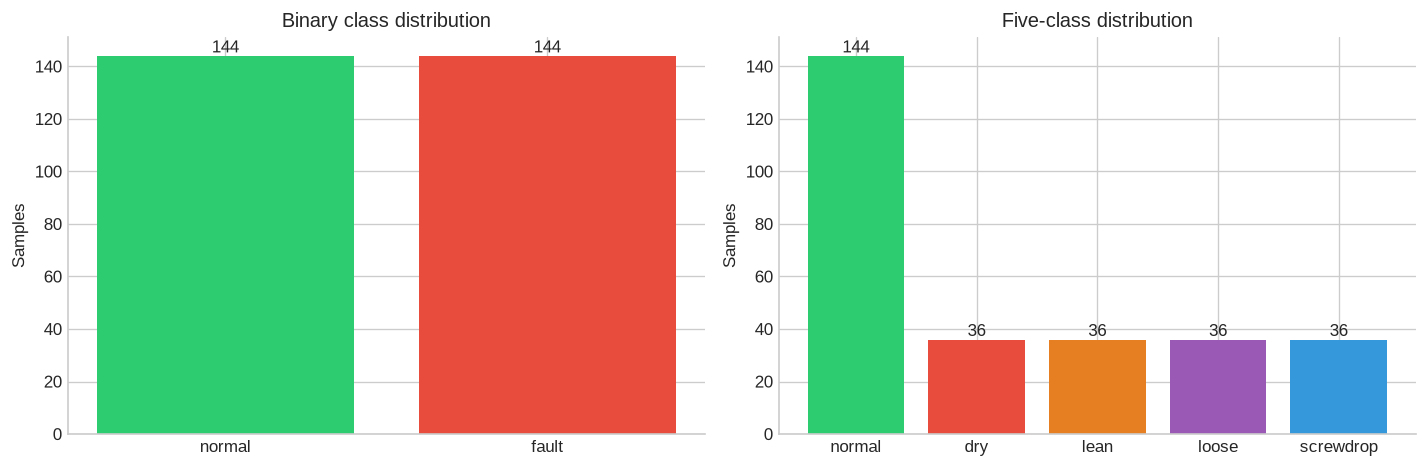


Note: If the compact set is heavily imbalanced, class weights must be used during training.


In [15]:
# ── Section 3-A: class distribution ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary
binary_counts = meta_df["is_fault"].value_counts().rename({0: "normal", 1: "fault"})
axes[0].bar(["normal", "fault"], [binary_counts.get("normal", 0), binary_counts.get("fault", 0)],
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Binary class distribution")
axes[0].set_ylabel("Samples")
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

# Five-class
class_counts = meta_df["fault"].value_counts()
colors = [PALETTE.get(c, "grey") for c in class_counts.index]
axes[1].bar(class_counts.index, class_counts.values, color=colors)
axes[1].set_title("Five-class distribution")
axes[1].set_ylabel("Samples")
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda" / "class_distribution.png", bbox_inches="tight")
plt.show()
print("\nNote: If the compact set is heavily imbalanced, class weights must be used during training.")

2026-09-11 22:08:54,260 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-11 22:08:54,263 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


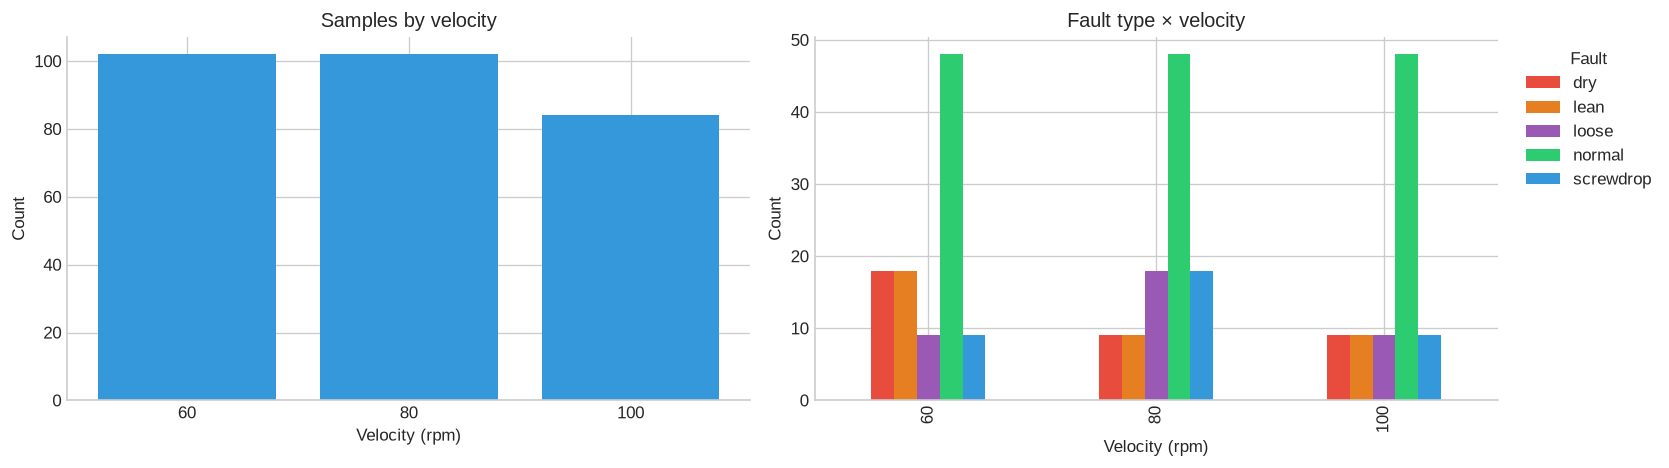

In [16]:
# ── Section 3-B: velocity distribution ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vel_counts = meta_df["velocity"].value_counts().sort_index()
axes[0].bar(vel_counts.index.astype(str), vel_counts.values, color="#3498db")
axes[0].set_title("Samples by velocity")
axes[0].set_xlabel("Velocity (rpm)")
axes[0].set_ylabel("Count")

# Fault × velocity
fv_pivot = meta_df.groupby(["velocity", "fault"]).size().unstack(fill_value=0)
fv_pivot.plot(kind="bar", ax=axes[1], color=[PALETTE.get(c, "grey") for c in fv_pivot.columns])
axes[1].set_title("Fault type × velocity")
axes[1].set_xlabel("Velocity (rpm)")
axes[1].set_ylabel("Count")
axes[1].legend(title="Fault", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.savefig(OUT_DIR / "eda" / "velocity_distribution.png", bbox_inches="tight")
plt.show()

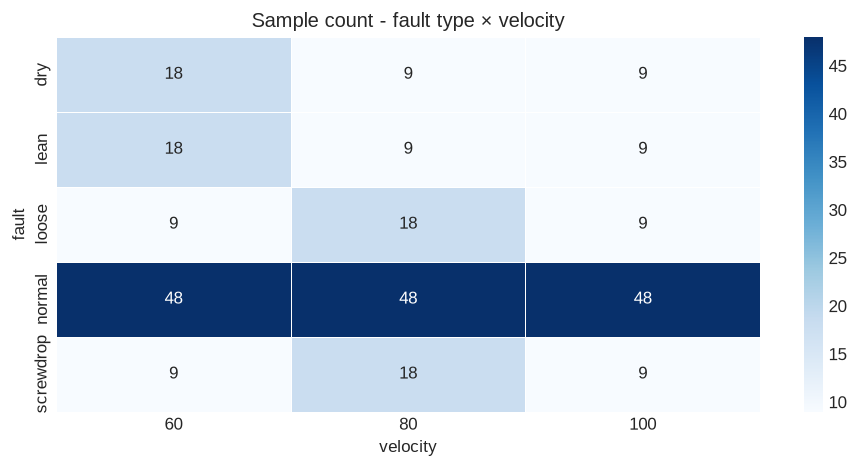

Unique load values: ['med']
Unique noise values: ['clean']

! If load and noise each have only one value in this compact set, results DO NOT generalise across load/noise conditions not represented here.


In [17]:
# ── Section 3-C: condition heatmap ────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))
heatmap_data = meta_df.groupby(["fault", "velocity"]).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Sample count - fault type × velocity")
plt.tight_layout()
plt.savefig(OUT_DIR / "eda" / "condition_heatmap.png", bbox_inches="tight")
plt.show()

# Load/noise coverage note
if "load" in meta_df.columns:
    print("Unique load values:", sorted(meta_df["load"].dropna().unique()))
if "noise" in meta_df.columns:
    print("Unique noise values:", sorted(meta_df["noise"].dropna().unique()))
print(
    "\n! If load and noise each have only one value in this compact set, "
    "results DO NOT generalise across load/noise conditions not represented here."
)

---
# 4. Temporal / Index Analysis

The key question: can `source_index` be interpreted as a temporal ordering within a condition?

**Important caveat:** The compact dataset is a *selected subset* of the full SSCC archive. Selected indices within a condition may have gaps. We analyse spacing before claiming temporal continuity.

source_index available: True

Per-condition index statistics:
    fault  velocity load noise  n_selected  idx_min  idx_max  median_spacing  max_gap  temporal_span_s
      dry        60  med clean        18.0      1.0     69.0             4.0      4.0            340.0
      dry        80  med clean         9.0      1.0     56.0             7.0      7.0            275.0
      dry       100  med clean         9.0      1.0     64.0             8.0      8.0            315.0
     lean        60  med clean        18.0      1.0     58.0             3.0      4.0            285.0
     lean        80  med clean         9.0      1.0     57.0             7.0      7.0            280.0
     lean       100  med clean         9.0      1.0     56.0             7.0      7.0            275.0
    loose        60  med clean         9.0      1.0     73.0             9.0      9.0            360.0
    loose        80  med clean        18.0      1.0     96.0             6.0      6.0            475.0
    loose  

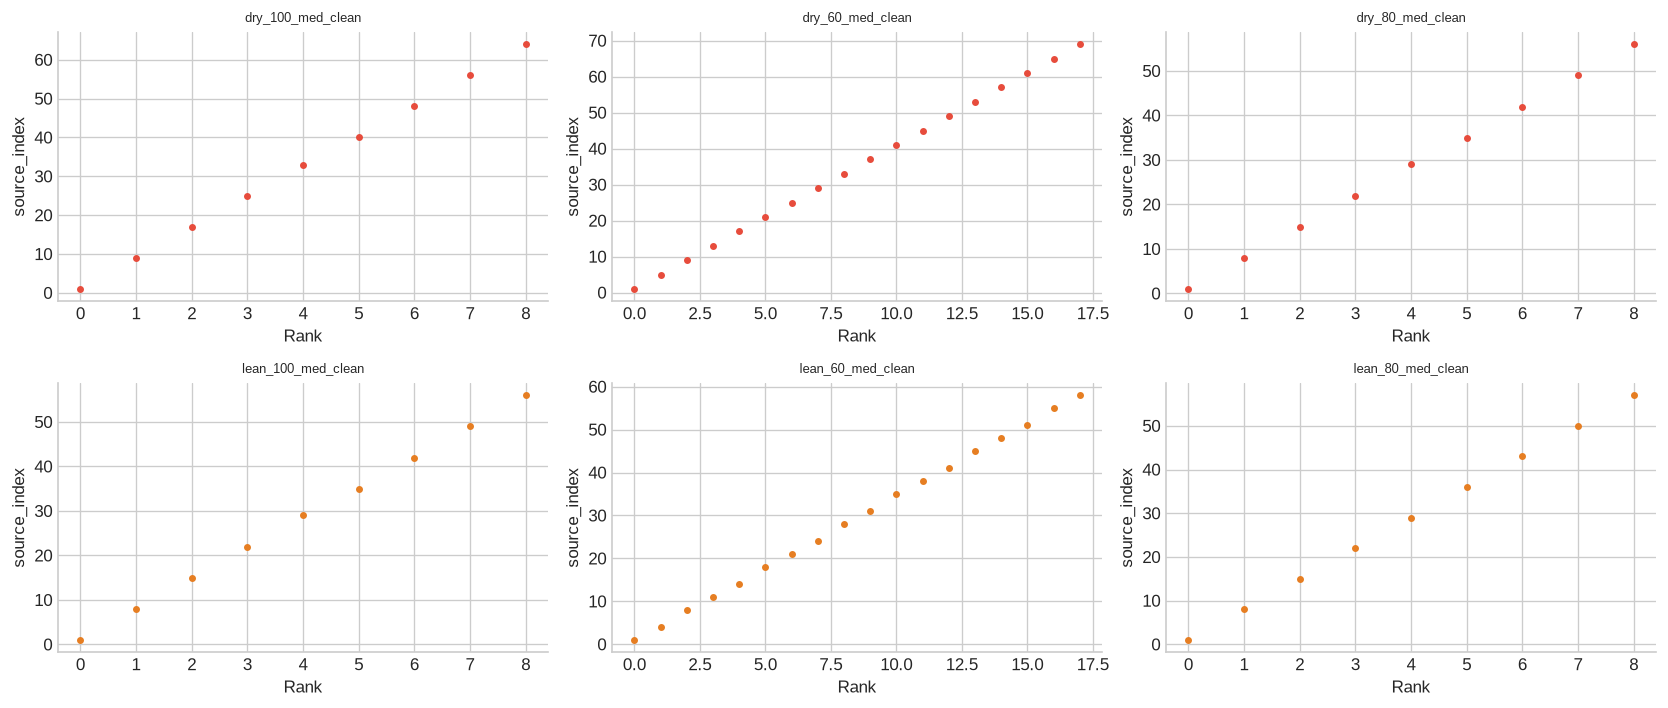


! The compact dataset contains SELECTED (not consecutive) samples. Gaps between selected source indices mean temporal continuity within a condition is only approximate. ACF/PACF and ARIMA analyses are exploratory only.


In [18]:
# ── Section 4-A: source index analysis ───────────────────────────────────────

if "source_index" not in meta_df.columns:
    # Try to parse from sample_id (e.g. 'med_vel60_clean_normal_0042')
    idx_pat = re.compile(r"_(\d{3,6})$")
    meta_df["source_index"] = meta_df["sample_id"].str.extract(idx_pat, expand=False).astype(float)
    log.warning("source_index inferred from sample_id tail digits.")

has_source_index = meta_df["source_index"].notna().any()
print(f"source_index available: {has_source_index}")

if has_source_index:
    # Per-condition index statistics
    group_cols = ["fault", "velocity"]
    if "load" in meta_df.columns: group_cols.append("load")
    if "noise" in meta_df.columns: group_cols.append("noise")

    def _index_stats(grp: pd.DataFrame) -> pd.Series:
        idx = grp["source_index"].dropna().sort_values()
        diffs = idx.diff().dropna()
        return pd.Series({
            "n_selected": len(idx),
            "idx_min":    idx.min(),
            "idx_max":    idx.max(),
            "median_spacing": diffs.median(),
            "max_gap":    diffs.max(),
            "temporal_span_s": (idx.max() - idx.min()) * CLIP_DURATION_S if len(idx) > 1 else 0,
        })

    idx_stats = meta_df.groupby(group_cols).apply(_index_stats).reset_index()
    print("\nPer-condition index statistics:")
    print(idx_stats.to_string(index=False))

    # Plot selected indices for representative conditions
    rep_conditions = meta_df[group_cols].drop_duplicates().head(6)
    fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=False)
    axes = axes.flatten()
    for i, (_, row) in enumerate(rep_conditions.iterrows()):
        mask = pd.Series([True] * len(meta_df))
        for c in group_cols:
            mask &= (meta_df[c] == row[c])
        grp = meta_df[mask].sort_values("source_index")
        ax = axes[i]
        ax.scatter(range(len(grp)), grp["source_index"], s=10, color=PALETTE.get(row.get("fault", "normal"), "grey"))
        label = "_".join(str(row[c]) for c in group_cols)
        ax.set_title(label, fontsize=8)
        ax.set_xlabel("Rank")
        ax.set_ylabel("source_index")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "eda" / "temporal_index_analysis.png", bbox_inches="tight")
    plt.show()

    print(
        "\n! The compact dataset contains SELECTED (not consecutive) samples. "
        "Gaps between selected source indices mean temporal continuity within a condition "
        "is only approximate. ACF/PACF and ARIMA analyses are exploratory only."
    )
else:
    print("source_index not available - temporal ordering analysis skipped.")

---
# 5. Raw Signal Loading Helpers

We define functions to load vibration and audio for any `sample_id`. These are called in both the EDA sections and the feature extraction pipeline.

In [19]:
# ── Section 5-A: signal loaders ───────────────────────────────────────────────

def load_vibration(sample_id: str) -> np.ndarray:
    """Load 4-channel vibration array from shard. Returns shape (4, T)."""
    shard_path = _shard_path_for(sample_id)
    key = f"{sample_id}.vib.npz"
    with tarfile.open(shard_path, "r:") as tf:
        raw = tf.extractfile(tf.getmember(key)).read()
    return _decode_vib(raw)


def load_audio(sample_id: str) -> Tuple[np.ndarray, int]:
    """Load recorder audio from shard. Returns (float32 mono, sample_rate)."""
    shard_path = _shard_path_for(sample_id)
    key = f"{sample_id}.audio.flac"
    with tarfile.open(shard_path, "r:") as tf:
        raw = tf.extractfile(tf.getmember(key)).read()
    return _decode_audio(raw)


def validate_vib(arr: np.ndarray, sample_id: str) -> bool:
    """Basic shape and finiteness checks for a vibration array."""
    expected_len = int(VIB_STORED_HZ * CLIP_DURATION_S)
    if arr.ndim != 2:
        log.error("%s: vib ndim=%d, expected 2", sample_id, arr.ndim)
        return False
    if arr.shape[0] < 1 or arr.shape[0] > 8:
        log.error("%s: vib channels=%d unexpected", sample_id, arr.shape[0])
        return False
    if arr.shape[1] < expected_len * 0.8:
        log.error("%s: vib length=%d too short (expected ~%d)", sample_id, arr.shape[1], expected_len)
        return False
    if not np.isfinite(arr).all():
        log.error("%s: vib contains non-finite values", sample_id)
        return False
    return True


def validate_audio(wav: np.ndarray, sr: int, sample_id: str) -> bool:
    """Basic checks for an audio array."""
    expected_len = int(sr * CLIP_DURATION_S)
    if wav.ndim != 1:
        log.error("%s: audio ndim=%d, expected 1 (mono)", sample_id, wav.ndim)
        return False
    if len(wav) < expected_len * 0.8:
        log.error("%s: audio length=%d too short", sample_id, len(wav))
        return False
    if not np.isfinite(wav).all():
        log.error("%s: audio non-finite", sample_id)
        return False
    return True


print("Signal loaders defined.")

Signal loaders defined.


In [20]:
import pandas as pd
import joblib
# Save state to disk for modular execution
meta_df.to_parquet(OUT_DIR / '02_prep_state.parquet', index=False)
audit_df.to_parquet(OUT_DIR / '02_audit_state.parquet', index=False)
joblib.dump(raw_inventory, OUT_DIR / '02_raw_inventory.pkl')
print('Data preparation complete. State saved.')


Data preparation complete. State saved.
